# Comparing Word-Space and Motion-Space Similarity

In this notebook we compare **semantic similarity** between prompts in text space  
(with BERT embeddings) to **motion similarity** between their generated motions  
(with DTW distances on the hand trajectories).

The goal is to answer:

> *“When two prompts are semantically close in language space, are their motions also similar?”*

We do this by:
1. Loading precomputed **distance matrices**:
   - `word_matrix`: pairwise distances in **BERT word space**  
   - `motion_matrix`: pairwise distances in **motion space** (DTW)
2. Building **k-nearest-neighbour (k-NN) sets** in each space.
3. Comparing the overlap between the k-NN sets from both spaces.
4. Computing 3 quantitative metrics:
   - \(P_1\): “at least one neighbour in common”
   - \(P_s\): “strictly identical neighbour sets”
   - \(P_\%\): “average percentage of overlap”
5. Visualizing the distance structure and (optionally) the k-NN graphs.
]]

## 1. Load Precomputed Distances and Labels

In this section we:

- Load `word_matrix` and `motion_matrix` from disk.  
  Each is a square \(|V| \times |V|\) matrix, where \(|V|\) is the number of prompts.
  - Entry \([i, j]\) stores the distance between prompt *i* and prompt *j*:
    - In **word space**: distance between BERT embeddings
    - In **motion space**: DTW distance between two motion sequences
- Load `word_labels`: a list of the original text prompts / token labels.
- Optionally create `short_labels` for plotting, so axis labels stay readable.

Assumption: the **row/column ordering** of both matrices matches the ordering of `word_labels`.
]]

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
DATA_DIR = Path(".")

# ---------------------------
# Load word-space data
# ---------------------------
word_matrix = np.load(DATA_DIR / "word_space_dist_matrix.npy")
with open(DATA_DIR / "word_space_labels.json", "r") as f:
    word_labels = json.load(f)

print("Word matrix shape:", word_matrix.shape)
print("First 5 word labels:", word_labels[:5])


# ---------------------------
# Load motion-space data
# ---------------------------
motion_matrix = np.load(DATA_DIR / "motion_space_dtw_matrix.npy")
with open(DATA_DIR / "motion_space_labels.json", "r") as f:
    motion_labels = json.load(f)

print("\nMotion matrix shape:", motion_matrix.shape)
print("First 5 motion labels:", motion_labels[:5])

# ---------------------------
# Safety check: ensure same order
# ---------------------------
assert word_labels == motion_labels, \
    "ERROR: Word-space and motion-space labels do not match. Check ordering."

labels = word_labels  # unified label set
N = len(labels)

print("\nAll labels aligned:", N, "items")


Word matrix shape: (20, 20)
First 5 word labels: ['p005-gopro_009', 'p013-fastfood-sandwich_080', 'p025-firstaid_017', 'p017-baking_027', 'p005-instrument-makeup-dog-packing-massage-firstaid-cleaning-tool_198']

Motion matrix shape: (20, 20)
First 5 motion labels: ['p005-gopro_009', 'p013-fastfood-sandwich_080', 'p025-firstaid_017', 'p017-baking_027', 'p005-instrument-makeup-dog-packing-massage-firstaid-cleaning-tool_198']

All labels aligned: 20 items


In [10]:
def shorten(s, max_len=20):
    """Shorten label strings for graph axes."""
    return s if len(s) <= max_len else s[:max_len] + "..."
def shorten_all(strings, max_len=20):
    return [shorten(s, max_len) for s in strings]


## 2. Visualize Distance Structure as Heatmaps

Here we create side-by-side heatmaps:

- **Left**: `word_matrix` — semantic distances between prompts  
- **Right**: `motion_matrix` — motion distances between generated trajectories

For readability we:

- Use the same ordering of samples on both axes.
- Use a diverging color map (e.g. `RdYlGn_r`) where:
  - Darker / greener = *more similar* (smaller distance)
  - Redder / brighter = *less similar* (larger distance)
- Optionally shorten labels (e.g. `short_labels`) and rotate tick labels so that text fits.

Interpretation:

- Blocks / clusters on the **word-space** heatmap show prompts that BERT thinks are semantically similar.
- Blocks / clusters on the **motion-space** heatmap show prompts with similar hand motions.
- If the two heatmaps look similar, it suggests that “language clusters” and “motion clusters” are aligned.
]]

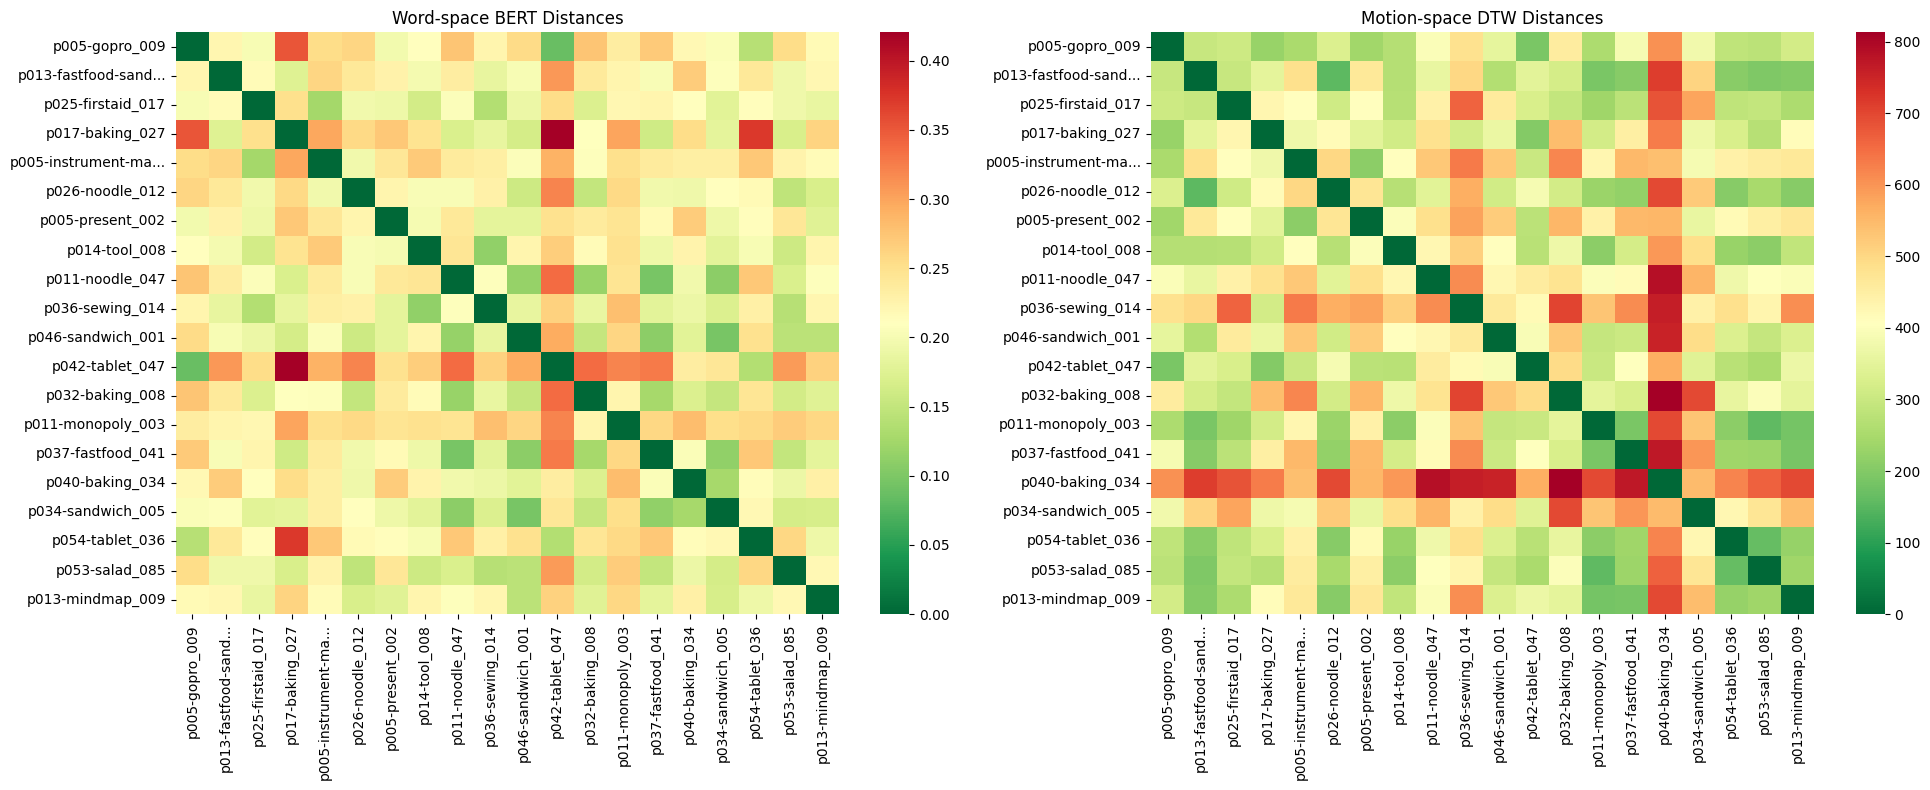

In [ ]:
plt.figure(figsize=(20, 8))
short_labels = shorten_all(word_labels, max_len=18)



# --- Word-space ---
plt.subplot(1, 2, 1)
sns.heatmap(
    word_matrix,
    cmap="RdYlGn_r",
    xticklabels=short_labels,
    yticklabels=short_labels
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Word-space BERT Distances")

# --- Motion-space ---
plt.subplot(1, 2, 2)
sns.heatmap(
    motion_matrix,
    cmap="RdYlGn_r",
    xticklabels=short_labels,
    yticklabels=short_labels
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Motion-space DTW Distances")

plt.tight_layout()
plt.show()


In [4]:
# Flatten matrices
w_flat = word_matrix.flatten()
m_flat = motion_matrix.flatten()

corr = np.corrcoef(w_flat, m_flat)[0, 1]
print("Correlation between word-space and motion-space:", corr)


Correlation between word-space and motion-space: 0.2609890527511522


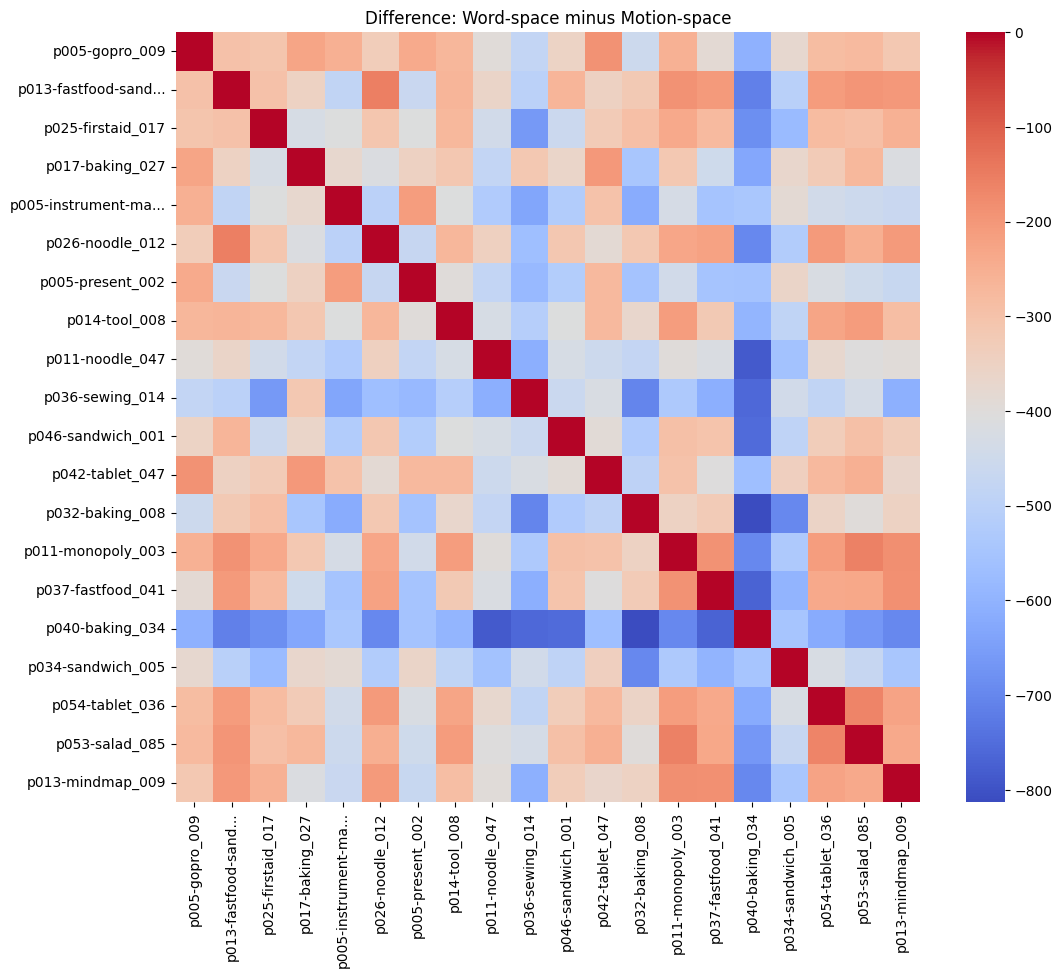

In [13]:
diff = word_matrix - motion_matrix

plt.figure(figsize=(12, 10))
sns.heatmap(diff, cmap="coolwarm",    xticklabels=short_labels,
    yticklabels=short_labels)
plt.title("Difference: Word-space minus Motion-space")
plt.show()



## k-NN Construction + Metric Computation

In this step we:

### 🔹 1. Build k-Nearest-Neighbour sets  
Using `get_knn()`, we take each distance matrix (word-space + motion-space)  
and extract, for every prompt, the **k closest neighbours** (excluding itself).

This gives two lists:
- `W_k[i]` — semantic neighbours  
- `S_k[i]` — motion neighbours  

### 🔹 2. Compute our 3 alignment metrics  
With `compute_overlap_metrics()`, we compare these neighbour sets and calculate:

1. **P₁** — whether each prompt has *at least one* shared neighbour  
2. **Pₛ** — whether the *entire* neighbour set matches exactly  
3. **P%** — average fraction of shared neighbours across all prompts  

These metrics tell us how similarly the prompts are structured in  
**word space vs motion space**.



In [ ]:
def get_knn(dist_matrix, k):
    """
    For each item i, return the indices of the k nearest neighbours
    (excluding itself).
    """
    N = dist_matrix.shape[0]
    knn = []

    for i in range(N):
        # argsort sorted by distance
        order = np.argsort(dist_matrix[i])
        # remove self
        order = order[order != i]
        # take nearest k
        knn.append(order[:k].tolist())

    return knn


def compute_overlap_metrics(W_k, S_k, k):
    """
    Compute the 3 cross-modal consistency metrics:
      P1  = at-least-one-overlap %
      Ps  = strict-set-match %
      P%  = average percent overlap %
    """
    N = len(W_k)
    assert N == len(S_k)

    at_least_one = 0
    strict_match = 0
    overlap_total = 0

    for w in range(N):
        set_W = set(W_k[w])
        set_S = set(S_k[w])

        overlap = len(set_W & set_S)

        if overlap >= 1:
            at_least_one += 1

        if overlap == k:
            strict_match += 1

        overlap_total += overlap

    P1  = (at_least_one / N) * 100
    Ps  = (strict_match / N) * 100
    Pp  = (overlap_total / (N * k)) * 100

    return P1, Ps, Pp


In [15]:
k = 5

W_k = get_knn(word_matrix, k)
S_k = get_knn(motion_matrix, k)

P1, Ps, Pp = compute_overlap_metrics(W_k, S_k, k)

print(f"P₁ (At least one overlap): {P1:.2f}%")
print(f"P_s (Strict match):        {Ps:.2f}%")
print(f"P_% (Average overlap):     {Pp:.2f}%")


P₁ (At least one overlap): 85.00%
P_s (Strict match):        0.00%
P_% (Average overlap):     23.00%
